In [95]:
import numpy as np
import matplotlib.pyplot as plt

$$
\begin{cases}
\partial_t u - \partial_{xx} u &= 0 \quad &{J\times G}\\
u(0,x) &= u_0(x)\quad &{G}\\
u(t,x)|_{x = 0} &= 0 \quad &{J} \\
\partial_x u(t,x)|_{x=1} &= 0 \quad &{J}
\end{cases}
$$


Discretized in matrix form:

$$
(\theta k h^{-2} \text{tridiag}(-1,2,-1)+I-e_{-1,-2}) \underline{u}^{m+1}+((1-\theta)kh^{-2}\text{tridiag}(-1,2,-1)-e_{-1,-2}-I)\underline{u}^m = k \underline{F}^m
$$

which yields:

$$
\underline{u}^{m+1}= (\theta k h^{-2} \text{tridiag}(-1,2,-1)-e_{-1,-2}+I)^{-1} \left(k \underline{F}^m-((1-\theta)kh^{-2}\text{tridiag}(-1,2,-1)-e_{-1,-2}-I)\underline{u}^m \right)
$$

note that in our simple case $k\underline{F}^m$ = 0

For simplicity, let $u(0,x) = \sin(\pi/2 x)$ 

In [96]:
def u0(x):
    return np.sin(np.pi/2 * x)

def solver(theta,N,M):
    h = 1/N
    k = 1/M
    G = np.diag([2]*N,k=0)+np.diag([-1]*(N-1),k=-1)+np.diag([-1]*(N-1),k=1)
    G[-1,-2] -= 1
    C = theta*k*(h**(-2))*G+np.identity(N)
    C_inv = np.linalg.pinv(C)
    B = -((1-theta)*k*(h**(-2))*G-np.identity(N))

    u = np.zeros((N,M+1))
    u[:,0] = u0(np.linspace(0+h,1-h,num=N))
    A = (C_inv @ B)
    for i in range(1,M+1):
        u[:,i] = A @ u[:,i-1]

        if i % 1000 == 0:
            print(f"{i}/{M}")
            print(u[0:10,i])

    return u[:,-1]



In [97]:
N = 2**4; M = 4**4

u_sol = solver(0.5,N,M)

In [98]:
h = 1/N
k = 1/M
u_true = np.exp(-np.pi**2 / 4 )*np.sin(np.pi / 2 * np.linspace(0+h,1-h,num=N))

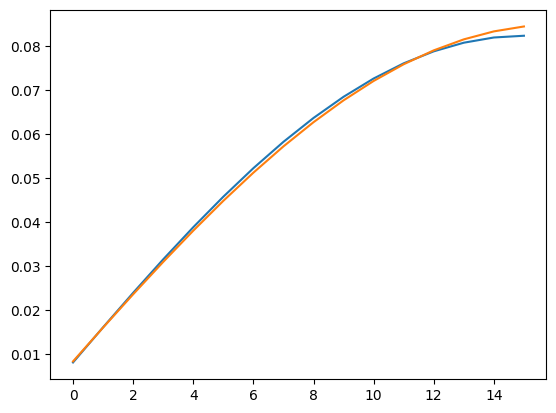

In [99]:
plt.plot(u_sol)
plt.plot(u_true)

plt.show()